# ENTRENAMIENTO DE MODELOS
---

### Clasificación de galaxias según su morfología

#### Integrantes
- `Crespo Neri, Diego Ubaldo` (`ubaldo.crespo@iteso.mx`)
- `Garibay Zepeda, Julio Andrés` (`julio.garibay@iteso.mx`)
- `Vázquez Sandoval, Isaac Ernesto` (`isaac.vazquez@iteso.mx`)

---

### Bibliotecas

In [23]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
import tensorflow as tf

In [24]:
# Swag
style = "/home/toutl/code/.machine.mplstyle"
if os.path.exists(style):
    plt.style.use(style)

---

### Data:

In [25]:
data_folder = Path("../../data/classification/")
# original_folder = data_folder / "original"
processed_folder = data_folder / "processed"

In [26]:
# Metadata
metadata_df = pd.read_csv(processed_folder / "galaxy_morphology.csv").astype(str)
display(metadata_df.head())

,image_id,class
0,3,S
1,4,S
2,6,S
3,7,S
4,13,E


In [27]:
# Files
processed_images = np.load(processed_folder / "processed_images.npz")
files = processed_images.files
print(np.array(files[:15]))

['3' '4' '6' '7' '13' '19' '20' '30' '32' '33' '34' '35' '37' '38' '40']


In [47]:
imgsused = 15000
data = np.array([processed_images[i] for i in files[:imgsused]])

In [29]:
data = np.array(data)

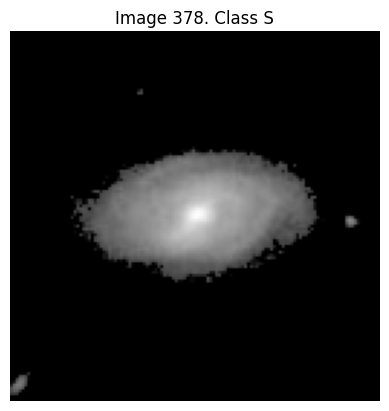

In [30]:
# Ejemplo
img_name = files[119]
idx = metadata_df.index[metadata_df["image_id"] == img_name][0]
img_class = metadata_df.at[idx, "class"]

plt.imshow(processed_images[img_name], cmap="gray")
plt.title(f"Image {img_name}. Class {img_class}")
plt.axis("off")
plt.show()

---

### Modelo 1. CNN:

In [48]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense, BatchNormalization
from keras.models import Sequential
from keras.optimizers import Adam

def build_binary_cnn():
    model = Sequential()

    model.add(Conv2D(filters=16, kernel_size=3, padding="same", activation="relu",
                     input_shape=(128, 128, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=32, kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2))
    
    model.add(Conv2D(filters=128, kernel_size=3, padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2))

    model.add(Dropout(0.3))

    model.add(Flatten())
    
    model.add(Dense(64, activation="relu")) 
    model.add(Dropout(0.4))

    model.add(Dense(1, activation="sigmoid"))
    
    optimizer = Adam(learning_rate=1e-4)
    model.compile(loss="binary_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    
    return model

In [49]:
# from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#Callbacks para el fit del modelo, funcionan para encontrar el mejor epoch
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [50]:
cnn_model = build_binary_cnn()
cnn_model.summary()

/home/fddf/.venv/venvp/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,633 (2.37 MB)

 Trainable params: 621,601 (2.37 MB)

 Non-trainable params: 32 (128.00 B)

In [51]:
metadata_df['class'].value_counts()

class
S    41433
E    29036
A      154
Name: count, dtype: int64

In [52]:
from sklearn.model_selection import train_test_split

y = metadata_df['class'][:imgsused].map({"S":0, "E":1, "A":0})

x_train, x_test ,y_train, y_test = train_test_split(data,y, random_state=1, shuffle=True)

x_test = np.array(x_test).astype("float32")
y_test = np.array(y_test).astype("float32")
x_train =np.array(x_train).astype("float32")
y_train= np.array(y_train).astype("float32")

In [53]:
y = np.array(y)
display(data.shape,y[:,np.newaxis].shape)

(15000, 128, 128)

(15000, 1)

In [54]:
hist_cnn = cnn_model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20


2025-11-20 12:32:47.748632: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 737280000 exceeds 10% of free system memory.


352/352 ━━━━━━━━━━━━━━━━━━━━ 117s 322ms/step - accuracy: 0.5619 - loss: 0.6880 - val_accuracy: 0.5752 - val_loss: 0.6888
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 395ms/step - accuracy: 0.5641 - loss: 0.6869 - val_accuracy: 0.5752 - val_loss: 0.6834
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 135s 384ms/step - accuracy: 0.5646 - loss: 0.6848 - val_accuracy: 0.5752 - val_loss: 0.6823
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 133s 379ms/step - accuracy: 0.5653 - loss: 0.6842 - val_accuracy: 0.5752 - val_loss: 0.6825
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.5649 - loss: 0.6834

KeyboardInterrupt: 

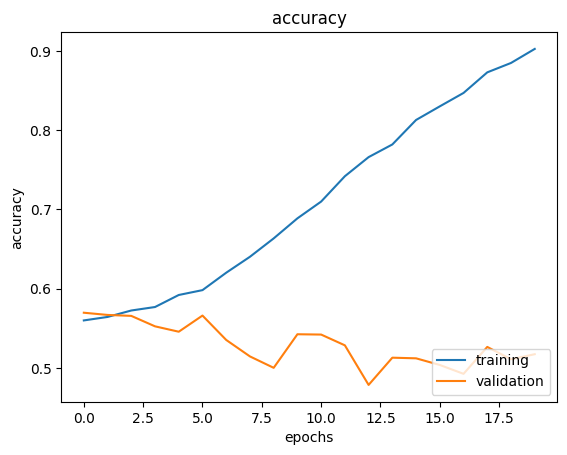

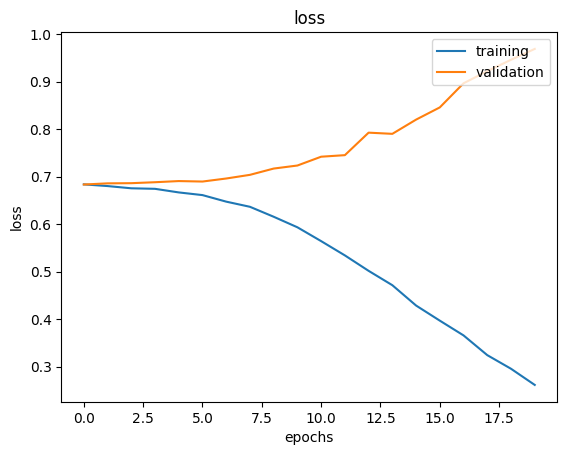

In [41]:
plt.plot(hist_cnn.history['accuracy'])
plt.plot(hist_cnn.history['val_accuracy'])
plt.title('accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['training', 'validation'], loc='lower right')
plt.show()

# training vs validation loss
plt.plot(hist_cnn.history['loss'])
plt.plot(hist_cnn.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(['training', 'validation'], loc='upper right')
plt.show()